In [1]:
import avalanche as av
import networkx as nx
import numpy as np
import random
import time
import gudhi
import matplotlib.pyplot as plt

## This notebook contains all examples, figures and tables from the avalanche homology manuscript.  

Note that vertices in the code are indexed from 0, but in the manuscript indexing starts at 1.

# Figure 3

In [2]:
# The directed path on 5 vertices, with an additional sink connected to the final vertex
P5 = nx.DiGraph()
P5.add_edges_from([(i,i+1) for i in range(4)])
sinks = [4]

# The initial configuration
c1 = [1,1,0,1,0]

# Get adjacency matrix of the graph
P5_M = nx.adjacency_matrix(P5).todense()

# Compute the avalanche homology
print("Firing sets:")
av_P5 = av.avalanche_complex(P5_M,c1,sinks=sinks, print_firings=True).betti_numbers()
print()

# Print the result
print("av(P_5,"+str(c1)+") =",av_P5)

Firing sets:
t = 0  :  [0, 1, 3]
t = 1  :  [1, 2, 4]
t = 2  :  [2, 3]
t = 3  :  [3, 4]
t = 4  :  [4]

av(P_5,[1, 1, 0, 1, 0]) = [1, 2, 0]


# Example 2.8

In [3]:
# The cycle on three vertices, with one bidirectional edge, and the sink connected the the final vertex
C3 = nx.DiGraph()
C3.add_edges_from([(0,1),(1,2),(0,2),(2,0)])
sinks = [2]

c2 = [5,0,0]

# Get adjacency matrix of the graph
C3_M = nx.adjacency_matrix(C3).todense()

# Compute the avalanche homology
print("Firing sets:")
av_C3 = av.avalanche_complex(C3_M,c2,sinks=sinks, print_firings=True).betti_numbers()
print()

# Print the result
print("av(G,"+str(c2)+") =",av_C3)

Firing sets:
t = 0  :  [0]
t = 1  :  [0, 1]
t = 2  :  [1, 2]
t = 3  :  [0, 2]
t = 4  :  [1]
t = 5  :  [2]
t = 6  :  [0]
t = 7  :  [1]
t = 8  :  [2]

av(G,[5, 0, 0]) = [1, 1, 0]


# Table 2

In [ ]:
n = 300
p = 0.05
reps = 25
rng = np.random.default_rng(612)

def ER_time(n,p,k,rng,nerve=True):
    G = nx.adjacency_matrix(nx.erdos_renyi_graph(n,p,directed=True,seed=rng)).todense()
    sinks = [i for i in range(n)]
    c = [25 if i in rng.choice(range(n),k) else 0 for i in range(n)]
    start = time.time()
    if nerve:
        _ = av.avalanche_complex(G,c,sinks=sinks,persistence=False).betti_numbers()
    else:
        _ = av.avalanche_complex_original(G,c,sinks=sinks,persistence=False).betti_numbers()
    end = time.time()
    return end-start

print("Average time to compute homology of the nerve complex of the avalanche complex:")
for k in range(1,21):
    nerve_timing.append(np.mean([ER_time(n,p,k*5,rng,nerve=True) for i in range(reps)]))
    print("k =",k*5," : time = ",nerve_timing[-1])

# Below will take a long time, then crash and run out of memory, as seen in the bottom row of Table 2
#if True:
if False:
    print()
    print("Average time to compute homology of avalanche complex:")
    rng = np.random.default_rng(612)
    avalanche_complex_timing = []
    for k in range(1,21):
        avalanche_complex_timing.append(np.mean([ER_time(n,p,k*5,rng,nerve=False) for i in range(reps)]))
        print("k =",k*5," : time = ",avalanche_complex_timing[-1])


Average time to compute homology of the nerve complex of the avalanche complex:
k = 5  : time =  0.0012005996704101563
k = 10  : time =  0.0012136268615722656
k = 15  : time =  0.0012487411499023438
k = 20  : time =  0.0011852931976318358
k = 25  : time =  0.0012819862365722656
k = 30  : time =  0.0013206291198730468
k = 35  : time =  0.0012769317626953125
k = 40  : time =  0.001317138671875
k = 45  : time =  0.0013622379302978516
k = 50  : time =  0.0014964580535888673
k = 55  : time =  0.0014641284942626953
k = 60  : time =  0.001443967819213867
k = 65  : time =  0.0016092300415039063
k = 70  : time =  0.001774740219116211
k = 75  : time =  0.0018332195281982422
k = 80  : time =  0.00210515022277832
k = 85  : time =  0.002593536376953125
k = 90  : time =  0.0021582794189453124
k = 95  : time =  0.0042011642456054685
k = 100  : time =  0.0042578792572021485

Average time to compute homology of avalanche complex:
k = 5  : time =  0.0011347484588623046
k = 10  : time =  0.00325406074523

# Example 3.2

In [4]:
# The directed path on 5 vertices, with an additional sink connected to the final vertex
P5 = nx.DiGraph()
P5.add_edges_from([(i,i+1) for i in range(4)])
sinks = [4]

# The initial configuration
c3 = [2,0,1,0,0]

# Get adjacency matrix of the graph
P5_M = nx.adjacency_matrix(P5).todense()

# Compute the avalanche homology
print("Firing sets:")
av_P5 = av.avalanche_complex(P5_M,c3,sinks=sinks, print_firings=True).betti_numbers()
print()

# Print the result
print("av(P_5,"+str(c3)+") =",av_P5)

Firing sets:
t = 0  :  [0, 2]
t = 1  :  [0, 1, 3]
t = 2  :  [1, 2, 4]
t = 3  :  [2, 3]
t = 4  :  [3, 4]
t = 5  :  [4]

av(P_5,[2, 0, 1, 0, 0]) = [1, 3, 0]


# Example 3.8

In [5]:
# The directed path on 7 vertices, with an additional sink connected to the final vertex
P7 = nx.DiGraph()
P7.add_edges_from([(i,i+1) for i in range(6)])
sinks = [6]

# The initial configuration
c4 = [1,0,0,1,0,0,1]

# Get adjacency matrix of the graph
P7_M = nx.adjacency_matrix(P7).todense()

# Compute the avalanche homology
print("Firing sets:")
av_P7 = av.avalanche_complex(P7_M,c4,sinks=sinks, print_firings=True).betti_numbers()
print()

# Print the result
print("av(P_7,"+str(c4)+") =",av_P7)

Firing sets:
t = 0  :  [0, 3, 6]
t = 1  :  [1, 4]
t = 2  :  [2, 5]
t = 3  :  [3, 6]
t = 4  :  [4]
t = 5  :  [5]
t = 6  :  [6]

av(P_7,[1, 0, 0, 1, 0, 0, 1]) = [3]


# Example 3.13

In [6]:
# The directed cycle on 4 vertices, without a sink
C4 = nx.DiGraph()
C4.add_edges_from([(0,1),(1,2),(2,3),(3,0)])
sinks = []

# The initial configuration
c5 = [1,1,1,0]

# Get adjacency matrix of the graph
C4_M = nx.adjacency_matrix(C4).todense()

# Compute the avalanche homology
print("Firing sets:")
av_C4 = av.avalanche_complex(C4_M,c5,sinks=sinks, print_firings=True).betti_numbers()
print()

# Print the result
print("av(C4,"+str(c5)+") =",av_P5)

Firing sets:
t = 0  :  [0, 1, 2]
t = 1  :  [1, 2, 3]
t = 2  :  [0, 2, 3]
t = 3  :  [0, 1, 3]
t = 4  :  [0, 1, 2]

av(C4,[1, 1, 1, 0]) = [1, 3, 0]


# Figure 5

In [7]:
C5 = nx.DiGraph()
C5.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,0)])
C5_M = nx.adjacency_matrix(C5).todense()
C6 = nx.DiGraph()
C6.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)])
C6_M = nx.adjacency_matrix(C6).todense()
sinks = []

c6 = [1,1,1,0,0]
c7 = [1,1,0,1,0]
c8 = [1,1,0,0,1,0]

print("av(C_5,"+str(c6)+") =",av.avalanche_complex(C5_M,c6,sinks=sinks).betti_numbers())
print("av(C_5,"+str(c7)+") =",av.avalanche_complex(C5_M,c7,sinks=sinks).betti_numbers())
print("av(C_6,"+str(c8)+") =",av.avalanche_complex(C6_M,c8,sinks=sinks).betti_numbers())

av(C_5,[1, 1, 1, 0, 0]) = [1, 1, 0]
av(C_5,[1, 1, 0, 1, 0]) = [1, 1, 0]
av(C_6,[1, 1, 0, 0, 1, 0]) = [1, 4, 0]


# Figure 6

In [8]:
# The directed cycle on 4 vertices, without a sink
C4 = nx.DiGraph()
C4.add_edges_from([(0,1),(1,2),(2,3),(3,0)])
C4_M = nx.adjacency_matrix(C4).todense()
sinks = []

all_c = [(0,0,0,0),(0,0,1,0),(0,1,0,0),(1,0,0,0),(0,1,1,0),(1,0,1,0),(1,1,0,0),(1,1,1,0)]

for c in all_c:
    print("av(C_4,"+str(c)+") =",av.avalanche_complex(C4_M,c,sinks=sinks).betti_numbers())

av(C_4,(0, 0, 0, 0)) = [1]
av(C_4,(0, 0, 1, 0)) = [4]
av(C_4,(0, 1, 0, 0)) = [4]
av(C_4,(1, 0, 0, 0)) = [4]
av(C_4,(0, 1, 1, 0)) = [1, 1]
av(C_4,(1, 0, 1, 0)) = [2]
av(C_4,(1, 1, 0, 0)) = [1, 1]
av(C_4,(1, 1, 1, 0)) = [1, 0, 1]


# Figure 7

In [9]:
C6_wedge = nx.DiGraph()
C6_wedge.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(0,6),(6,7),(7,8),(8,9),(9,10),(10,0)])
C6_wedge_M = nx.adjacency_matrix(C6_wedge).todense()
sinks = []
c9 = [2,1,0,1,0,0,1,0,1,0,0]
print("av(C_6^wedge,"+str(c9)+") =",av.avalanche_complex(C6_wedge_M,c9,sinks=sinks).betti_numbers())

av(C_6^wedge,[2, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0]) = [1, 4, 0]


# Table 3

In [10]:
# The undirected graph on 6 vertices, with the sink connected to the first vertex
P6_undirected = nx.DiGraph()
P6_undirected.add_edges_from([(i,i+1) for i in range(5)]+[(i+1,i) for i in range(5)])
sinks = [0]

uP6_M = nx.adjacency_matrix(P6_undirected).todense()

c10 = (1, 7, 0, 0, 2, 0)
c11 = (4, 5, 0, 2, 3, 0)
c12 = (7, 1, 2, 2, 2, 1)

print("av(P_3,"+str(c10)+") =",av.avalanche_complex(uP6_M,c10,sinks=sinks).betti_numbers())
print("av(P_3,"+str(c11)+") =",av.avalanche_complex(uP6_M,c11,sinks=sinks).betti_numbers())
print("av(P_3,"+str(c12)+") =",av.avalanche_complex(uP6_M,c12,sinks=sinks).betti_numbers())

av(P_3,(1, 7, 0, 0, 2, 0)) = [1, 1, 1, 0, 0, 0]
av(P_3,(4, 5, 0, 2, 3, 0)) = [1, 0, 0, 2, 0, 0]
av(P_3,(7, 1, 2, 2, 2, 1)) = [1, 0, 0, 0, 1]


# Figure 8

In [11]:
C6 = nx.DiGraph()
C6.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)])
C6_M = nx.adjacency_matrix(C6).todense()
sinks = []

c13 = [2,0,0,0,1,0]

print("Firing sets:")
av_C6 = av.avalanche_complex(C6_M,c13,sinks=sinks, print_firings=True, persistence=True).persistence(persistence_dim_max=True)

print()
print("Persistence pairs:")
for pair in av_C6:
    print("dim_"+str(pair[0])+" : "+str(pair[1]))

Firing sets:
t = 0  :  [0, 4]
t = 1  :  [0, 1, 5]
t = 2  :  [0, 1, 2]
t = 3  :  [1, 2, 3]
t = 4  :  [2, 3, 4]
t = 5  :  [3, 4, 5]
t = 6  :  [0, 4, 5]

Persistence pairs:
dim_1 : (4.0, inf)
dim_1 : (5.0, 6.0)
dim_0 : (0.0, inf)


# Figure 9

/home/phys3smithj/.local/lib/python3.8/site-packages/gudhi/persistence_graphical_tools.py:107: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


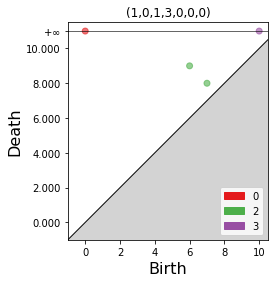

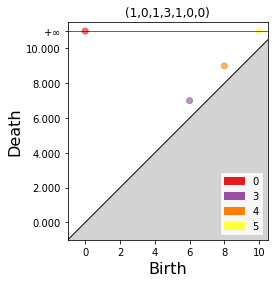

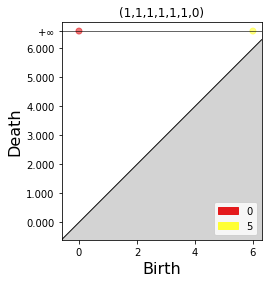

In [12]:
C7 = nx.DiGraph()
C7.add_edges_from([(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,0)])
C7_M = nx.adjacency_matrix(C7).todense()
sinks = []

c14 = [1,0,1,3,0,0,0]
c15 = [1,0,1,3,1,0,0]
c16 = [1,1,1,1,1,1,0]

av_C7a = av.avalanche_complex(C7_M,c14,sinks=sinks, print_firings=False, persistence=True).persistence(persistence_dim_max=True)
av_C7b = av.avalanche_complex(C7_M,c15,sinks=sinks, print_firings=False, persistence=True).persistence(persistence_dim_max=True)
av_C7c = av.avalanche_complex(C7_M,c16,sinks=sinks, print_firings=False, persistence=True).persistence(persistence_dim_max=True)

ax1 = gudhi.plot_persistence_diagram(av_C7a)
ax1.set_title('(1,0,1,3,0,0,0)')
ax1.set_aspect("equal")
ax2 = gudhi.plot_persistence_diagram(av_C7b)
ax2.set_title('(1,0,1,3,1,0,0)')
ax2.set_aspect("equal")
ax3 = gudhi.plot_persistence_diagram(av_C7c)
ax3.set_title('(1,1,1,1,1,1,0)')
ax3.set_aspect("equal")